In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
with open("../saved_models/features.json") as f:
    feature_names = json.load(f)

print("[INFO] Loaded feature list:", len(feature_names))

[INFO] Loaded feature list: 17


In [3]:
DATA_PATH = "../data/processed/featured_dataset.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

print("[INFO] Dataset loaded:", df.shape)
df.head()

[INFO] Dataset loaded: (43657, 19)


,timestamp,load_actual,temperature,humidity,dew_point,solar_generation,wind_generation,hour,day_of_week,month,is_weekend,hour_sin,hour_cos,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2015-01-07 23:00:00,28222.0,2.2,32,-12.6,52.0,1015.0,23,2,1,0,-0.258819,0.965926,31404.0,25555.0,22734.0,31718.583333,5933.401136,27376.958333
1,2015-01-08 00:00:00,25790.0,0.8,28,-15.6,43.0,1235.0,0,3,1,0,0.000000,1.000000,28222.0,23341.0,22734.0,31820.625000,5802.679387,27395.148810
2,2015-01-08 01:00:00,24481.0,-0.6,25,-18.0,36.0,1443.0,1,3,1,0,0.258819,0.965926,25790.0,22029.0,22734.0,31922.791667,5642.149945,27405.547619
3,2015-01-08 02:00:00,23883.0,-2.5,27,-19.2,36.0,1579.0,2,3,1,0,0.500000,0.866025,24481.0,21456.0,21286.0,32023.916667,5465.376314,27421.005952
4,2015-01-08 03:00:00,23761.0,-3.5,29,-19.2,36.0,1692.0,3,3,1,0,0.707107,0.707107,23883.0,21457.0,20264.0,32119.916667,5289.089097,27441.821429


In [4]:
TARGET = "load_actual"
DROP_COLS = ["timestamp", TARGET]

X = df.drop(columns=DROP_COLS)
y = df[TARGET]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx][feature_names]
X_test  = X.iloc[split_idx:][feature_names]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


Function to calculate Mean Absolute Percentage Error (MAPE)

In [5]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


LightGBM Regressor

In [6]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

mae_lgb  = mean_absolute_error(y_test, pred_lgb)
rmse_lgb = mean_squared_error(y_test, pred_lgb) ** 0.5
mape_lgb = mean_absolute_percentage_error(y_test, pred_lgb)

print("LightGBM Results")
print("MAE :", mae_lgb)
print("RMSE:", rmse_lgb)
print("MAPE:", mape_lgb)

joblib.dump(lgb_model, "../saved_models/lgb_model.pkl")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2716
[LightGBM] [Info] Number of data points in the train set: 34925, number of used features: 17
[LightGBM] [Info] Start training from score 28699.791382
LightGBM Results
MAE : 219.33774582197213
RMSE: 302.54296143605706
MAPE: 0.7759896126908911


['../saved_models/lgb_model.pkl']

CatBoost Regressor

In [7]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=False
)

cat_model.fit(X_train, y_train)
pred_cat = cat_model.predict(X_test)

mae_cat  = mean_absolute_error(y_test, pred_cat)
rmse_cat = mean_squared_error(y_test, pred_cat) ** 0.5
mape_cat = mean_absolute_percentage_error(y_test, pred_cat)

print("CatBoost Results")
print("MAE :", mae_cat)
print("RMSE:", rmse_cat)
print("MAPE:", mape_cat)

cat_model.save_model("../saved_models/catboost_model.cbm")


CatBoost Results
MAE : 201.6423727293093
RMSE: 278.1604666613613
MAPE: 0.7165981996412344


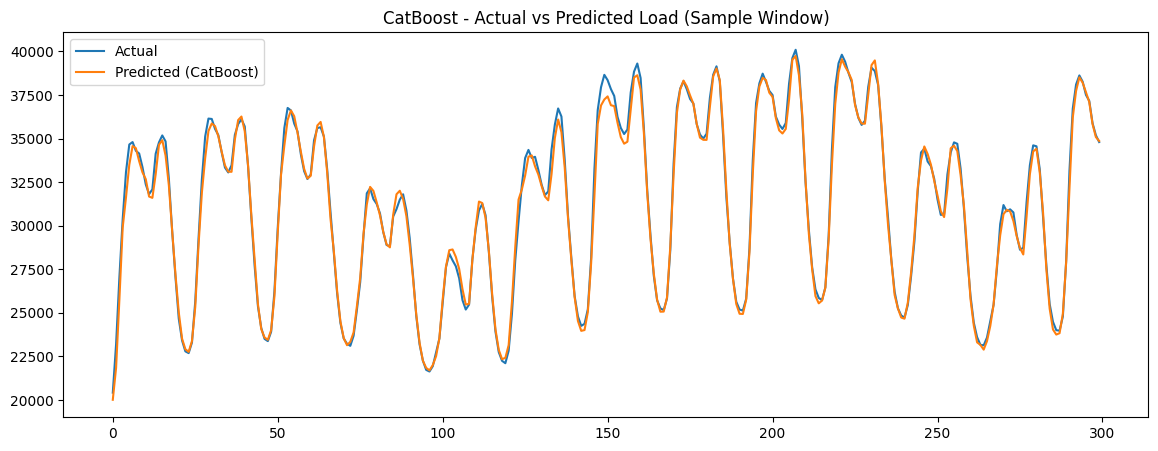

In [8]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred_cat[:300], label="Predicted (CatBoost)")
plt.legend()
plt.title("CatBoost - Actual vs Predicted Load (Sample Window)")
plt.show()
